Depois de calcular o fluxo calibrado de cada pixel (por exemplo F_B_calib):

In [ ]:
from astropy.io import fits

# Redefinir header se quiseres copiar do original
header_B = fits.getheader('m57_blue_bkg/m57_blue_bkg.fits')

# Criar novo FITS com os fluxos calibrados
hdu_B = fits.PrimaryHDU(F_B_calib, header=header_B)
hdu_B.writeto('m57_blue_calib.fits', overwrite=True)

# Repetir para V e R
header_V = fits.getheader('m57_green_bkg/m57_green_bkg.fits')
hdu_V = fits.PrimaryHDU(F_V_calib, header=header_V)
hdu_V.writeto('m57_green_calib.fits', overwrite=True)

header_R = fits.getheader('m57_red_bkg/m57_red_bkg.fits')
hdu_R = fits.PrimaryHDU(F_R_calib, header=header_R)
hdu_R.writeto('m57_red_calib.fits', overwrite=True)

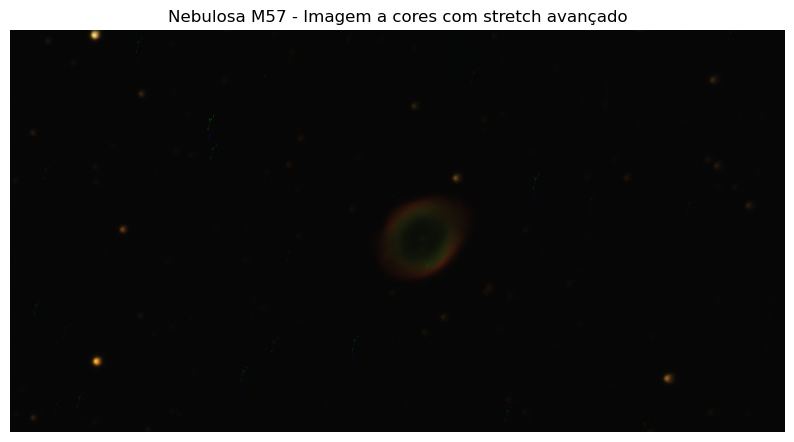

In [ ]:
import aplpy

aplpy.make_rgb_image('m57_red_calib.fits', 
                     'm57_green_calib.fits', 
                     'm57_blue_calib.fits', 
                     'M57_RGB.png',
                     stretch='asinh')





1️⃣ Determinar a frequência exata de cada filtro

Cada filtro (B, V, R) tem uma largura espectral e frequência central.

Saber a frequência permite:

Normalizar os fluxos por banda se quisermos comparar fluxos físicos reais (ex.: fluxos por Hz ou por λ).

Ajustar cores científicas reais, porque o azul, verde e vermelho não são apenas arbitrários, mas representam emissão física em cada banda.

Como integrar:

Depois de calibrar os fluxos em cada banda, podes dividir cada array pelo comprimento de onda efetivo ou largura do filtro, transformando fluxos em fluxos específicos por Hz (fν).

Isso faz a imagem RGB mais representativa fisicamente, em vez de apenas visual.

2️⃣ Usar a black (total)

Pelo que disseste, a “black” é a imagem sem filtro, ou uma imagem total (pode ser usada para referência de fundo ou intensidade total).

Pode ajudar em:

Normalizar a intensidade global da imagem: evita saturar regiões muito brilhantes.

Detectar pixels ruins ou artefatos: comparar cada banda com a black para remover flutuações que não são reais.

Ajustar contraste relativo: por exemplo, F_band / F_black para gerar um “mapa relativo de cores”, evitando que regiões muito escuras fiquem invisíveis.

Como integrar:

Carregar a imagem black e subtrair ou normalizar cada banda:

F_B_calib /= F_black
F_V_calib /= F_black
F_R_calib /= F_black
Depois aplicar stretch e criar RGB.